## Modelos basados en un parámetro

En este cuaderno se presenta el modelo binomial que depende de un parámetro $\theta$ y se puede trabajar a partir de dos distribuciones diferentes. La distribución uniforme con parámetro $1$ y la distribución beta con parámetros $\alpha$ y $\beta$.


***Información inicial (prior)*** El primer paso para trabajar en los métodos bayesianos consiste en establecer cómo se debe parametrizar la información inincial que tiende a ser subjetiva y que moldea el resultado final apoyada en las observaciones. Esta es la distribución prior y en ella se definen el valor de los parámetros iniciales. 

Existen dos interpretaciones básicas. En la interpretación de la población, la distribución a priori representa una población de posibles valores de parámetros, de la cual se ha extraído el $\theta$ de interés actual. En la interpretación más subjetiva del estado del conocimiento, el principio rector es que debemos expresar nuestro conocimiento (e incertidumbre) sobre $\theta$ como si su valor pudiera considerarse como una realización aleatoria de la distribución anterior.  Por lo general, la distribución a priori debe incluir todos los valores plausibles de $\theta$, pero la distribución no necesita concentrarse de manera realista alrededor del valor verdadero, porque a menudo la información sobre $\theta$ contenida en los datos superará con creces cualquier especificación de probabilidad previa razonable.@gelman(2013)


### Distribución Uniforme como información a priori


Para el modelo binomial, inicialmente se puede considerar como fuente de informaión a priori una distribución uniforme en la que el valor $\theta=1$ lo que implica que antes de generar el ejercicio hay un desconocimiento total de la información a priori y la probabilidad de obtener cualquier evento es la misma. Esto significa que basada en la información observada no es posible tener un valor inicial.

Para encontrar la distribución posterior se define entonces la siguientze ecuación usando la regla de bayes, $\theta \sim U(a,b)$ que es lo mismo que decir $P(a \leq \theta \leq b)$ Siendo la densidad uniforme se puede decir que $P(\theta)=1$ para cada $\theta \in [0,1]$.

\begin{align}
p(\theta \mid y_{1},...,y_{n}) &= \frac{p(y_{1},...,y_{n}\mid \theta)p(\theta)}{p( y_{1},...,y_{n})} & \\
&= p(y_{1},...,y_{n}\mid \theta) \times \frac{1}{p( y_{1},...,y_{n})} & \\
&\propto p(y_{1},...,y_{n}\mid \theta) 
\end{align}

Como $\theta$ no depende de las observaciones del denominador $p( y_{1},...,y_{n})$, se puede decir que el resultado de $p(\theta \mid y_{1},...,y_{n})$ es proporcional a $p(y_{1},...,y_{n}\mid \theta)$, lo que significa que tiene la misma forma pero no necesariamente la misma escala.

Para saber el valor de la escala, se puede normalizar la constante $1/p( y_{1},...,y_{n})$ usando el siguiente resultado:

$$\int_{0}^{1}\theta^{a-1}(1-\theta)^{b-1}d\theta = \frac{\Gamma(a)\Gamma(b)}{\Gamma(a+b)}$$

Dado que la suma de las probabilidad es igual a 1, es valido decir que 

$$1= \int_{0}^{1} p(\theta \mid y_{1},...,y_{n}) d\theta $$
$$1=  \int_{0}^{1}\frac{\theta^{\sum_{i=1}^{y}}(1-\theta)^{n-\sum_{i=1}^{y}}}{p( y_{1},...,y_{n})} d\theta$$
$$1= \frac{1}{p( y_{1},...,y_{n})} \int_{0}^{1} \theta^{\sum_{i=1}^{n}}(1-\theta)^{n-\sum_{i=1}^{n}} d\theta$$
$$1= \frac{1}{p( y_{1},...,y_{n})} \frac{\Gamma(a+1)\Gamma(b+1)}{\Gamma(a+b+2)}$$

Basado en lo anterior la distribución posterior de $\theta$ usando una distribución uniforme prior es:


\begin{align}
p(\theta \mid y) &= \frac{p(y \mid \theta)p(\theta)}{p(y)} & \\
&=  \frac{\binom{n}{k}\theta^{y}(1-\theta)^{n-y}p(\theta)}{p(y)} & \\
&=  c(y)\theta^{y}(1-\theta)^{n-y}p(\theta) 
\end{align}


Normalizando la constante y usando $p(\theta)=1$ la distribución posterior es una distribución beta.


\begin{align}
1 &= \int_{0}^{1} c(y) \theta^{y}(1-\theta)^{n-y} d\theta & \\
1 &= c(y) \int_{0}^{1}  \theta^{y}(1-\theta)^{n-y} d\theta& \\
1 &=  c(y) \frac{\Gamma(y+1)\Gamma(n-y+1)}{\Gamma(n+2)}
\end{align}

Remplazando se obtiene que 

\begin{align}
p(\theta \mid y) &= \frac{\Gamma(n+2)}{\Gamma(y+1)\Gamma(n-y+1)} \theta^{y}(1-\theta)^{n-y} & \\
&=  \frac{\Gamma(n+2)}{\Gamma(y+1)\Gamma(n-y+1)} \theta^{(y+1)-1}(1-\theta)^{(n-y+1)-1} & 
\end{align}

$$ =  beta(y+1,n-y+1)$$



Como se mencionó anteriomente, solo se tiene en cuenta la información de la que depende el parámetro $\theta$ el resto es constante la distribución posterior es $p(\theta \mid y) =beta(y+1,n-y+1)$


* La moda de esta distribución es $moda[\theta]=(a-1)/[(a-1)+(b-1)]$ 

* La media de esta distribución es $E[\theta]=a/(a+b)$

* La varianza de esta distribución es  $V[\theta]=ab/[(a+b+1)(a+b)^{2}]$


### Estudio de Mercado


La compañia de cable realizó una encuesta en la que pregunta por las preferencias entre dos plataformas de streaming. De 300 personas, 200 respondieron que preferian la plataforma A y 100 personas que preferian la plataforma B. La información que esta empresa tiene acerca de las preferencias es casi nula por lo que deciden establecer que la probabilidad de una persona se decida por una plataforma sea la misma. 


Dado que se asume completa ignorancia la información inicial es $P(\theta)=1$ siguiendo una distribución uniforme. Esto quiere decir que para encontrar la información posterior  se puede decir que:


* Las preferencias están dadas por $\theta =\sum_{i=1}^{N}Y_{i}/N$.
* $Y_{i}$ se distribuye iid 
* El modelo está condicionado a $\theta$



$$p(y_{1},...,y_{300}\mid \theta) = \theta^{\sum_{i=1}^{300}}(1-\theta)^{300-\sum_{i=1}^{300}}$$

$$p( \theta \mid y_{1},...,y_{300}) \propto \theta^{200+1}(1-\theta)^{300-200+1}$$



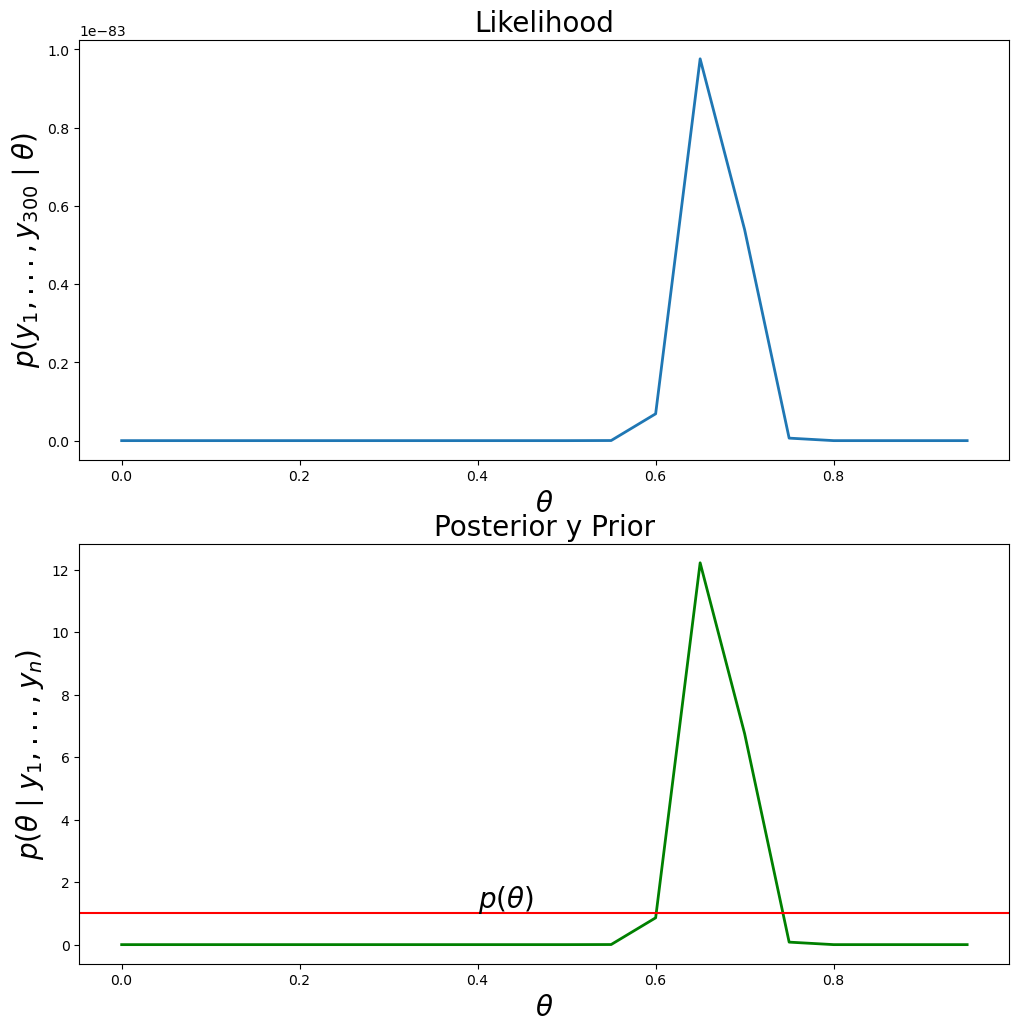

In [30]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from scipy.stats import binom
from scipy.stats import uniform
from scipy.stats import beta
import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

cero=np.zeros(100)
unos=np.ones(200)

survey=np.concatenate((cero, unos), axis=None)
sy=np.sum(survey) # 20, 50, 100, 150, 200, 250, 300 (Su semilla sumatoria dio 78)
n=len(survey)
theta = np.arange(0, 1, 0.05)


binom=theta**sy * (1-theta)**(n-sy)
betapost=[beta.pdf(r, sy+1,n-sy+1,0,1) for r in theta ]

## Se grafica la Likelihood, la prior y la posterior
plt.figure(figsize=(12, 12))
plt.subplot(2, 1, 1)
plt.plot(theta, binom, linewidth=2, markersize=12)
plt.title("Likelihood",fontsize=20)
plt.xlabel(r'$\theta$',fontsize=20)
plt.ylabel(r'$p(y_{1},...,y_{300}\mid \theta)$',fontsize=20)

plt.subplot(2, 1, 2)
plt.plot(theta, betapost, linewidth=2, markersize=12, color="green")
plt.axhline(y = 1, color = 'red')
plt.text(0.4, 1.2, r'$p(\theta)$',
         fontsize=20)
plt.title("Posterior y Prior",fontsize=20)
plt.xlabel(r'$\theta$',fontsize=20)
plt.ylabel(r'$p(\theta \mid y_{1},...,y_{n}) $',fontsize=20)


plt.show()



In [31]:
# Se obtienen las medidas
import pandas as pd
moda= sy/(sy+(n-sy))
media=(sy+1)/((sy+1)+(n-sy+1))
varianza=((sy+1)*(n-sy+1))/(((sy+1)+(n-sy+1)+1)*((sy+1)+(n-sy+1))**2)
data= [("moda", moda),("media", media),("varianza", varianza)]
df = pd.DataFrame(data)  
df  

,0,1
0,moda,0.666667
1,media,0.665563
2,varianza,0.000735


En promedio la probabilidad de que un suscriptor prefiera la plataforma A es 66.55% 

### Distribuciones conjugadas

Una figura especial se genera cuando la distribución a prior es la misma que la distribución posterior. Este es un caso de la distribución beta cuando se conjuga con la distribución binomial, el resultado es la misma distribución con un cambio en los praámetros producto del cálculo de la distribución posterior. En este caso los hyperparámetros de la distribución a priori sufren un cambio y se convierten en nuevos parámetros para dar lugar al resultado final.


\begin{align}
p(\theta \mid y) &= \frac{p(y \mid \theta)p(\theta)}{p(y)} & \\
&=  \frac{1}{p(y)}\times \frac{\Gamma(a+b)}{\Gamma(a) \Gamma(b)} \theta^{a-1}(1-\theta)^{b-1} \times \binom{n}{y}\theta^{y}(1-\theta)^{n-y} & \\
&=  c(n,y,a,b)\times \theta^{a+y-1}(1-\theta)^{b+n-y-1} 
\end{align}



$$p(\theta \mid y)= beta(a+y,b+n-y)$$

En el paper $\alpha_0=a$ y $\beta_0=b$ son los parámetros de la prior

Donde $\alpha=a+y$ y $\beta=b+n-y$ que son parámetros de la posterior

* El valor esperado $E[\theta \mid y]=\frac{a+y}{a+b+n}$

* la moda es $moda[\theta\mid y]=\frac{a+y-1}{a+b+n-2}$ 

* la varianza es $V[\theta \mid y]=\frac{E[\theta \mid y]E[1-\theta \mid y]}{a+b+n+1}=\frac{(a+y)(b+n-y)}{(a+b+n)^{2}(a+b+n+1)}$

Como se puede observar $p(\theta)=  \frac{\Gamma(a+b)}{\Gamma(a) \Gamma(b)} \theta^{a-1}(1-\theta)^{b-1}$ mientras que $p(\theta \mid y)$ es la misma distribución en donde cambian los parámetros.


### Estudio de Mercado

Usando el mismo estudio de mercado, se asume que el parámetro $\theta$ tiene una distribución beta con parámetros a y b. Con la información inicial se vuelve a obtener la distribución posterior. Para calcular los hyperparametros de la distribución, se puede considerar $a=\theta_{0}n_{0}$ y $b=(1-\theta_{0})n_{0}$. Encontrar los hyperparametros de un distrobución es una de las mayores dificultades de la estadística bayesiana, su mayor debilidad surge de la subjetividad de la información inicial y por lo tanto es muy importante tener muy claro qué tipo de información inicial se desea implementar para encontrar la distribución posterior. 

En este ejemplo, se asumira que existe un $\theta_{0}=60\%$ de probabilidad de escoger el servicio de streaming A y que la cantidad de suscriptores nuevos mensuales $n_{0}=10$, será la muestra inicial para obtener esos hyperparámetros 

Text(0, 0.5, '$p(\\theta)$')

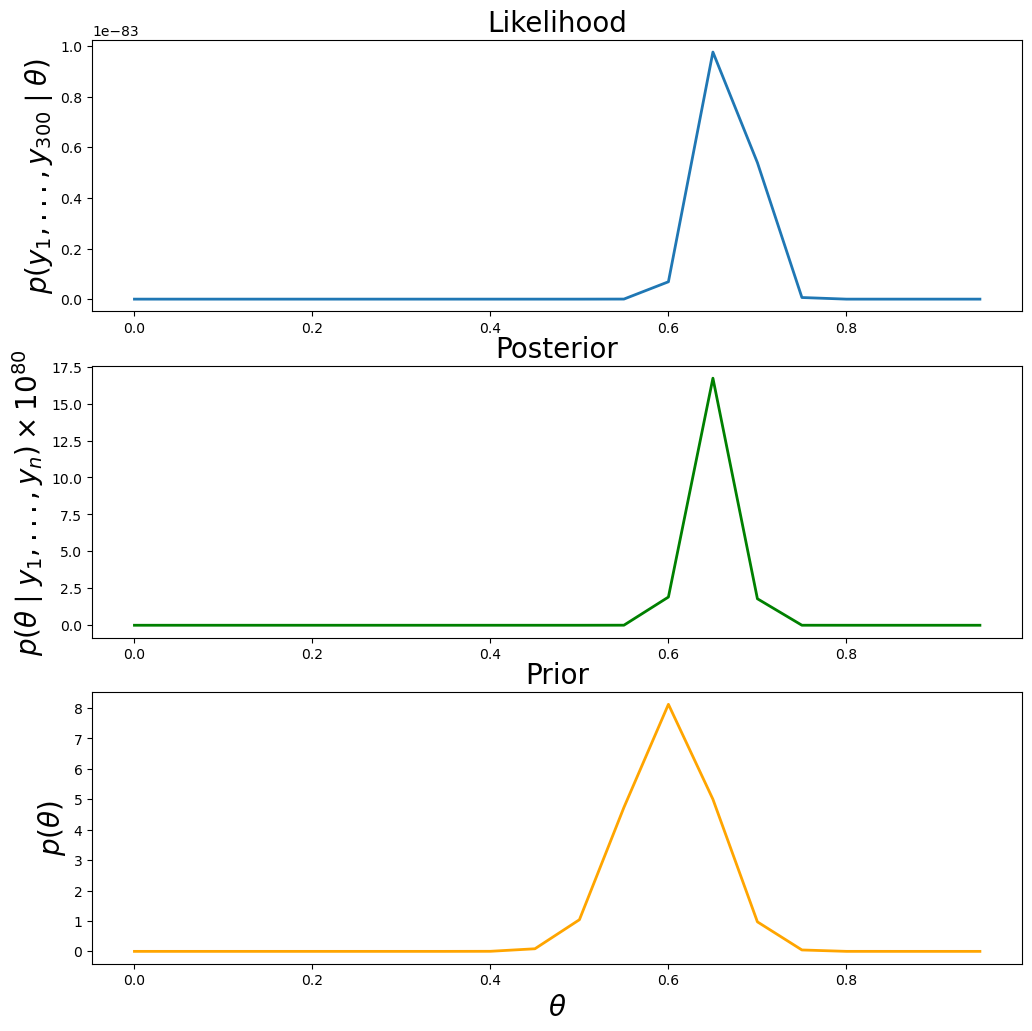

In [33]:
%matplotlib inline
a=0.6*100
b=0.4*100

betaprior= [beta.pdf(r, a,b,0,1) for r in theta ]
binom=theta**sy * (1-theta)**(n-sy)
betapost=[beta.pdf(r, a+sy,b+n-sy,0,1) for r in theta ]


## Se grafica la Likelihood, la prior y la posterior
plt.figure(figsize=(12, 12))
plt.subplot(3, 1, 1)
plt.plot(theta, binom, linewidth=2, markersize=12)
plt.title("Likelihood",fontsize=20)


plt.ylabel(r'$p(y_{1},...,y_{300}\mid \theta)$',fontsize=20)
plt.subplot(3, 1, 2)
plt.plot(theta, betapost, linewidth=2, markersize=12, color="green")
plt.title("Posterior",fontsize=20)

plt.ylabel(r'$p(\theta \mid y_{1},...,y_{n}) \times 10^{80}$',fontsize=20)
plt.subplot(3, 1, 3)
plt.plot(theta, betaprior, linewidth=2, markersize=12, color="orange")
plt.title("Prior",fontsize=20)
plt.xlabel(r'$\theta$',fontsize=20)
plt.ylabel(r'$p(\theta)$',fontsize=20)


In [34]:
moda=(a+sy-1)/(a+b+n-2)
media=(a+sy)/(a+b+n)
varianza=((a+sy)*(b+n-sy))/((a+b+n)**2*(a+b+n+1))
data= [("moda", moda),("media", media),("varianza", varianza)]
df = pd.DataFrame(data)  
df   

,0,1
0,moda,0.650754
1,media,0.650000
2,varianza,0.000567


### Intervalo Creibles

El intervalo para determinar el valor verdadero de $\theta$ se obtiene después de observar los datos, es decir cuando se calcula la distribución posterior. La diferencia con la estadística frecuentista o clásica es que este valor se obtiene antes de obsvervar los datos y su intepretación, es que por ejemplo el 95% de las veces un estimador caerá dentro de ciertos límites. 


$$P(l(Y)<\theta<u(Y)\mid \theta)=0.95$$

***Highest posterior density*** 

A $100 \times (1 − \alpha)\%$ HPD region consiste en un subconjunto de paramétros en un espacio $ s(y) \subset \theta$


$ P(\theta \in s(y)|Y =y)=1−\alpha$

Todos los puntos en una región HPD tienen una densidad posterior más alta que los puntos fuera de la región. Sin embargo, una región HPD podría no ser un intervalo si la densidad posterior es multimodal (con múltiples picos).

In [35]:
## Se obtienen los intervales de forma frecuentista y con la función posterior 
## de acuerdo a los valores
from scipy.stats import beta
import pandas as pd
quantprior=[beta.ppf(r, a,b,0,1) for r in theta ]
percen975prior= np.percentile(quantprior, 97.5, keepdims=True)
percen25prior= np.percentile(quantprior, 2.5, keepdims=True)
quantpost=[beta.ppf(r, a+sy,b+n-sy,0,1) for r in theta ]
percen975post= np.percentile(quantpost, 97.5, keepdims=True)
percen25post= np.percentile(quantpost, 2.5, keepdims=True)
data= [("Percentil 2.5 post", percen25post),("Percentil 97.5 post", percen975post), ("Percentil 2.5 prior", percen25prior),("Percentil 97.5 prior", percen975prior)]
df =pd.DataFrame(data)  
df  

,0,1
0,Percentil 2.5 post,[0.28993633043651107]
1,Percentil 97.5 post,[0.6847786861870386]
2,Percentil 2.5 prior,[0.2463524024460063]
3,Percentil 97.5 prior,[0.67107533995734]


### Predicción 


Una vez que se han observado los datos se puede predecir valor un observable desconocido,$\tilde{y}$, a partir del mismo proceso. Por ejemplo, $y = (y_{1},..., Y_{n})$ puede ser el vector de observaciones registradas $n$ veces con parámetros, $\theta = (p,n)$  La distribución de $\tilde{y}$ se denomina distribución predictiva posterior, porque está condicionada a la $y$ observada y predictiva porque es una predicción para una $\tilde{y}$ 
observable:


\begin{align}
p(\tilde{y} \mid y) &=\int p(\tilde{y},\theta \mid y) d\theta & \\
&=  \int p(\tilde{y} \mid \theta , y)p(\theta \mid y) d\theta & \\
&=  \int p(\tilde{y} \mid \theta) p(\theta \mid y) d\theta 
\end{align}

Para un modelo binario,  $\tilde{Y}\in \{0,1\}$ la distribución predictiva $\tilde{Y}$ dado $\theta$ y la distribución posterior de $\theta$. 


\begin{align}
p(\tilde{y} =1 \mid y) &=\int p(\tilde{y} =1 ,\theta \mid y) d\theta & \\
&=  \int p(\tilde{y} =1 \mid \theta , y)p(\theta \mid y) d\theta & \\
&=  \int \theta p(\theta \mid y) d\theta & \\
&= E(\theta \mid y)=\frac{a+\sum_{i=1}^{n}y_{i}}{a+b+n} 
\end{align}

$$P(\tilde{Y}=0\mid y) =1-E[\theta \mid y]=\frac{b+\sum_{i=1}^{n}(1-y_{i})}{a+b+n}$$



In [36]:
# En el ejemplo del estudio de mercado se pueder ver que el valor esperado del
# parámetro dado las observaciones es :


predic=(a+sy)/(a+b+n)
predic

0.65

El resultado sugiere que la probapilidad de que el próximo suscriptor escoja la plataforma de streaming a es 66.45%

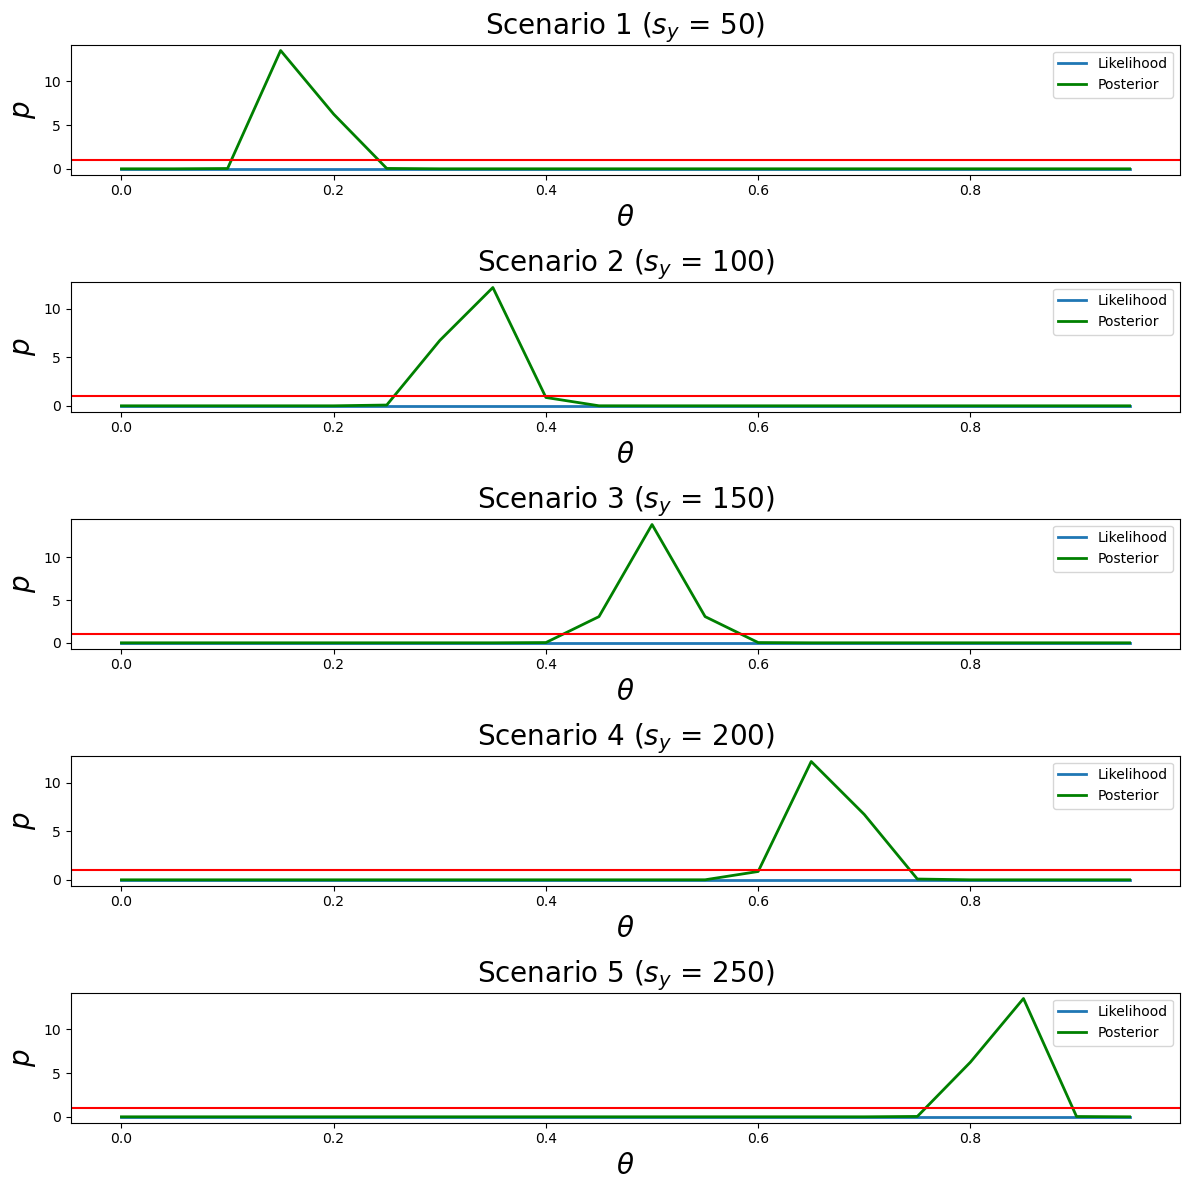

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta
import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# Define the number of scenarios
num_scenarios = 5

# Define different values of sy for each scenario
sy_values = [50, 100, 150, 200, 250]

# Create a grid of theta values
theta = np.arange(0, 1, 0.05)

# Initialize the figure
plt.figure(figsize=(12, 12))

for i, sy in enumerate(sy_values):
    n = 300  # Total number of samples
    binom_likelihood = theta**sy * (1-theta)**(n-sy) 
    betapost = [beta.pdf(r, sy+1, n-sy+1, 0, 1) for r in theta]

    # Create subplots for each scenario
    plt.subplot(num_scenarios, 1, i+1)
    plt.plot(theta, binom_likelihood, linewidth=2, markersize=12, label="Likelihood")
    plt.plot(theta, betapost, linewidth=2, markersize=12, color="green", label="Posterior")
    plt.axhline(y=1, color='red')
    plt.title(f"Scenario {i+1} ($s_y$ = {sy})", fontsize=20)
    plt.xlabel(r'$\theta$', fontsize=20)
    plt.ylabel(r'$p$', fontsize=20)
    plt.legend()

plt.tight_layout()
plt.show()


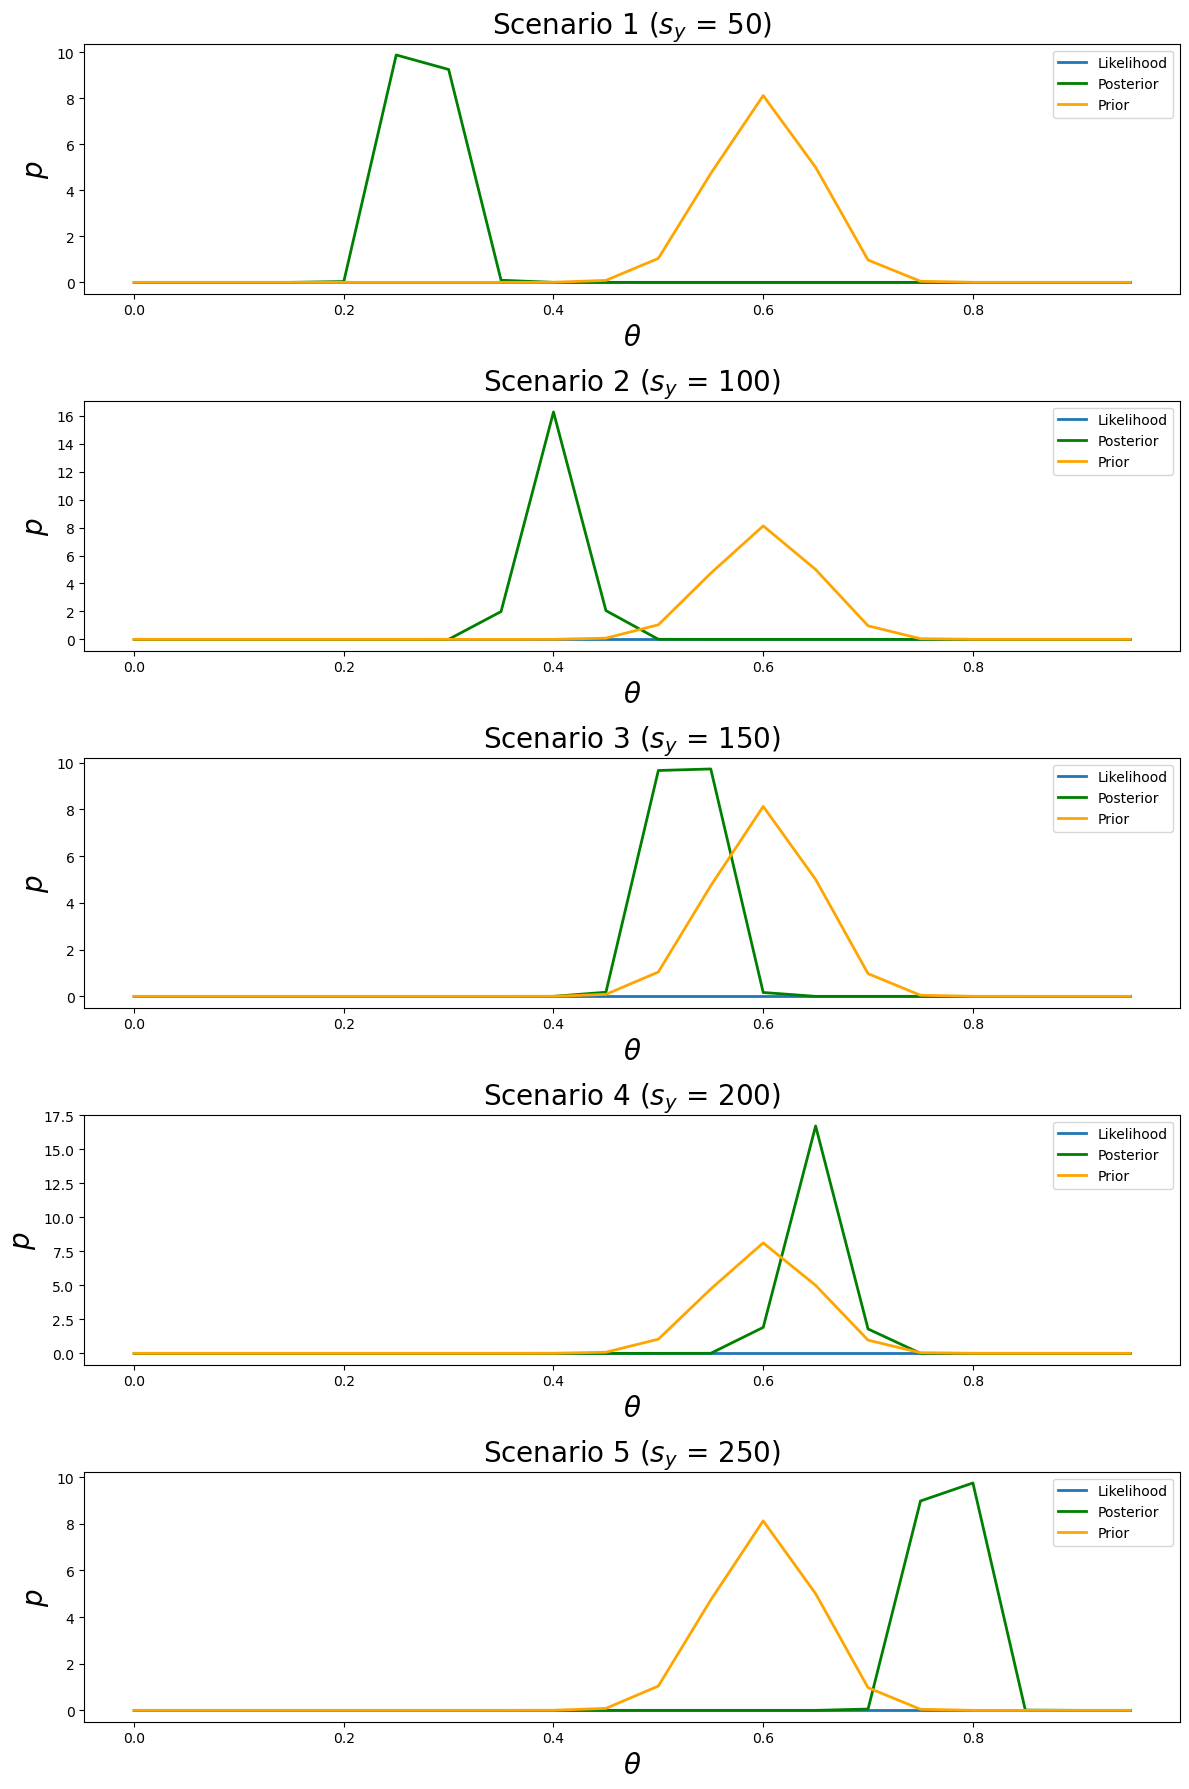

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta
import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# Define the number of scenarios
num_scenarios = 5

# Define different values of sy for each scenario
sy_values = [50, 100, 150, 200, 250]

# Define parameters for prior beta distribution
a_prior = 0.6 * 100
b_prior = (1 - 0.6) * 100

# Create a grid of theta values
theta = np.arange(0, 1, 0.05)

# Initialize the figure
plt.figure(figsize=(12, 18))

for i, sy in enumerate(sy_values):
    n = 300  # Total number of samples
    
    # Calculate parameters for the posterior beta distribution
    a_post = a_prior + sy
    b_post = b_prior + n - sy
    
    binom_likelihood = theta**sy * (1 - theta)**(n - sy) 
    betapost = [beta.pdf(r, a_post, b_post, 0, 1) for r in theta]
    betaprior = [beta.pdf(r, a_prior, b_prior, 0, 1) for r in theta]

    # Create subplots for each scenario
    plt.subplot(num_scenarios, 1, i + 1)
    plt.plot(theta, binom_likelihood, linewidth=2, markersize=12, label="Likelihood")
    plt.plot(theta, betapost, linewidth=2, markersize=12, color="green", label="Posterior")
    plt.plot(theta, betaprior, linewidth=2, markersize=12, color="orange", label="Prior")
    plt.title(f"Scenario {i+1} ($s_y$ = {sy})", fontsize=20)
    plt.xlabel(r'$\theta$', fontsize=20)
    plt.ylabel(r'$p$', fontsize=20)
    plt.legend()

plt.tight_layout()
plt.show()


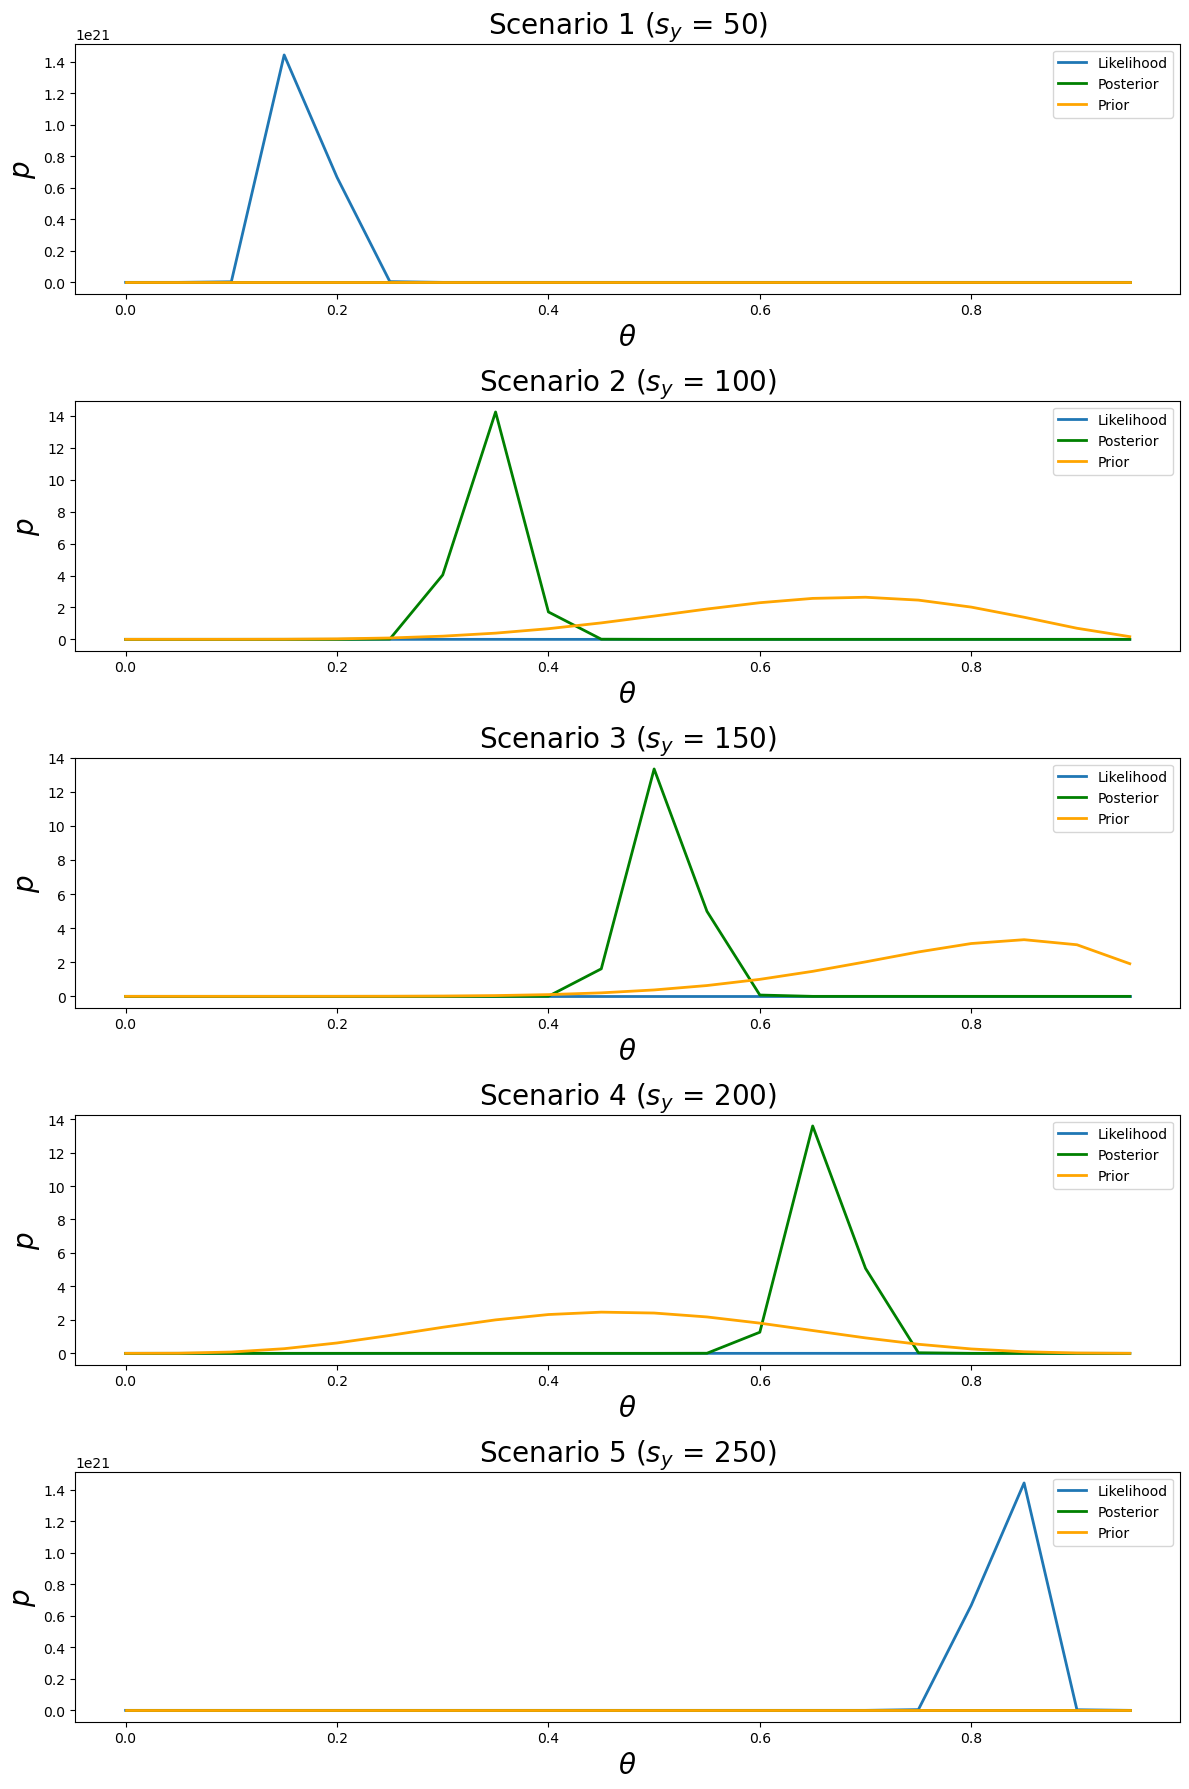

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta
import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# Define the number of scenarios
num_scenarios = 5

# Define different values of sy for each scenario
sy_values = [50, 100, 150, 200, 250]

# Create a grid of theta values
theta = np.arange(0, 1, 0.05)

# Initialize the figure
plt.figure(figsize=(12, 18))

for i, sy in enumerate(sy_values):
    n = 300  # Total number of samples
    
    # Generate random values of 'a' between 0.2 and 0.8
    a_prior = np.random.uniform(0.2, 0.8) * 10
    b_prior = (1 - a_prior / 10) * 10
    
    # Calculate parameters for the posterior beta distribution
    a_post = a_prior + sy
    b_post = b_prior + n - sy
    
    binom_likelihood = theta**sy * (1 - theta)**(n - sy) * 10**80
    betapost = [beta.pdf(r, a_post, b_post, 0, 1) for r in theta]
    betaprior = [beta.pdf(r, a_prior, b_prior, 0, 1) for r in theta]

    # Create subplots for each scenario
    plt.subplot(num_scenarios, 1, i + 1)
    plt.plot(theta, binom_likelihood, linewidth=2, markersize=12, label="Likelihood")
    plt.plot(theta, betapost, linewidth=2, markersize=12, color="green", label="Posterior")
    plt.plot(theta, betaprior, linewidth=2, markersize=12, color="orange", label="Prior")
    plt.title(f"Scenario {i+1} ($s_y$ = {sy})", fontsize=20)
    plt.xlabel(r'$\theta$', fontsize=20)
    plt.ylabel(r'$p$', fontsize=20)
    plt.legend()

plt.tight_layout()
plt.show()


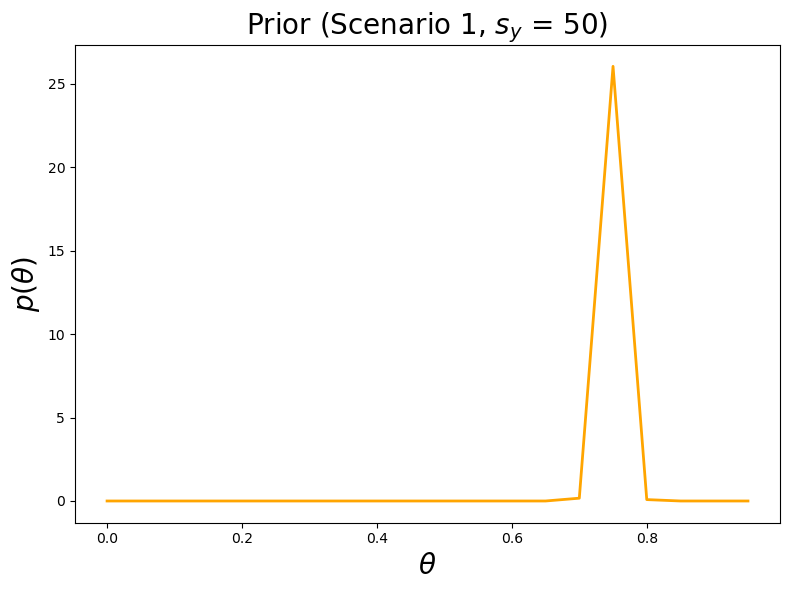

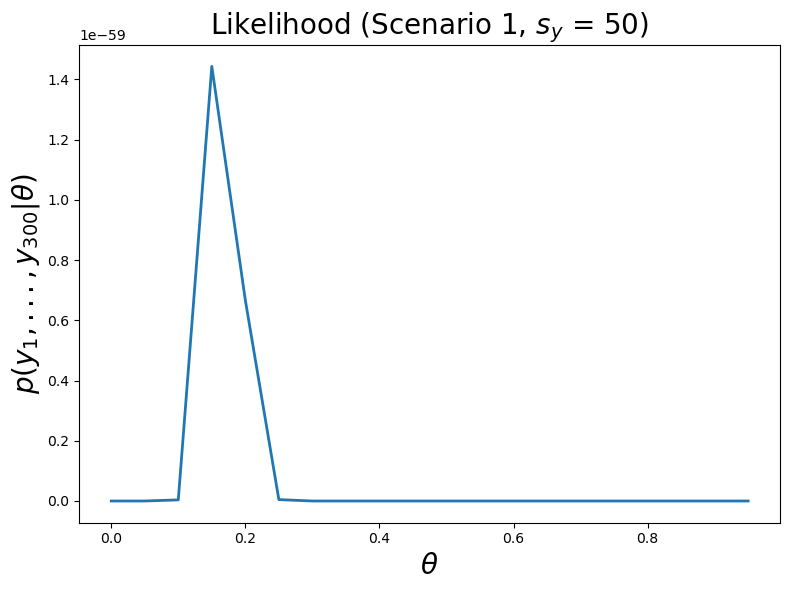

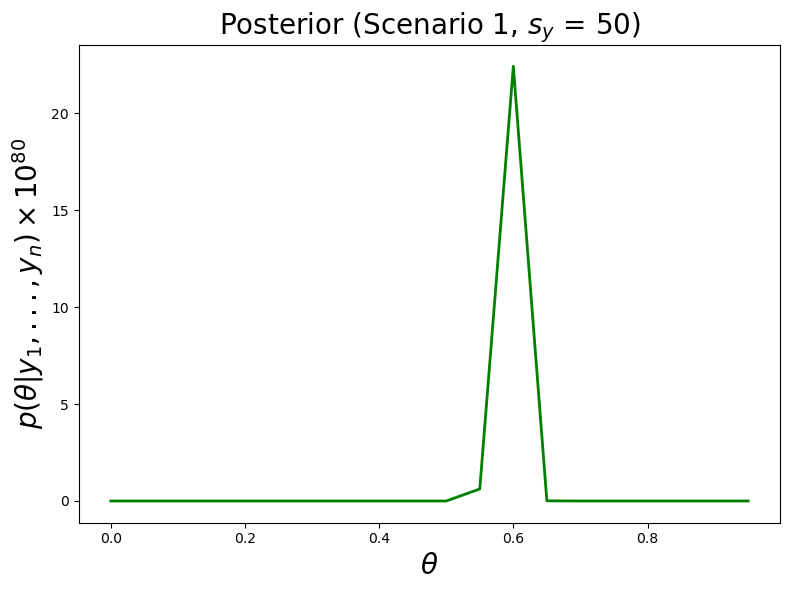

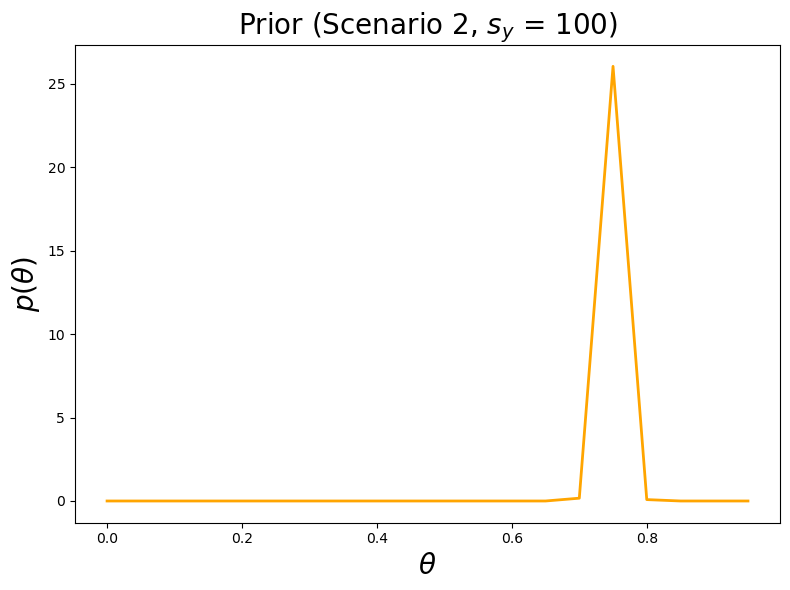

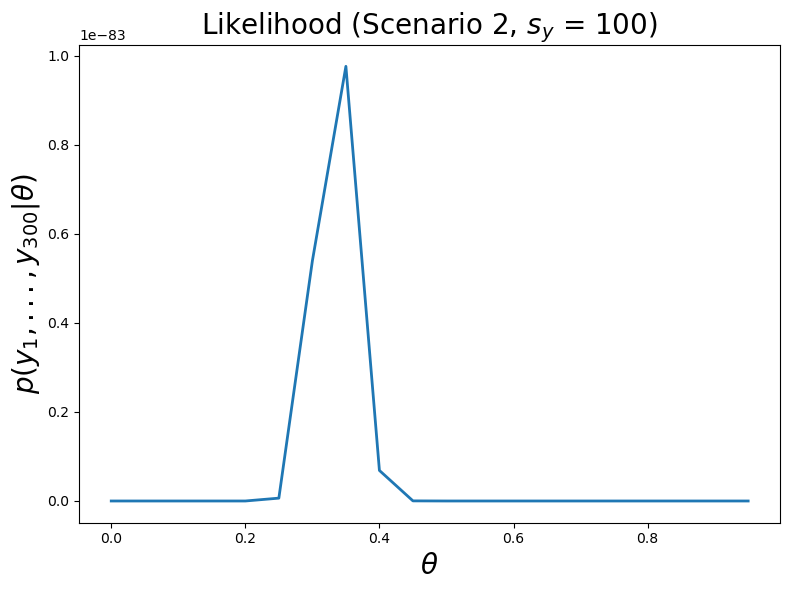

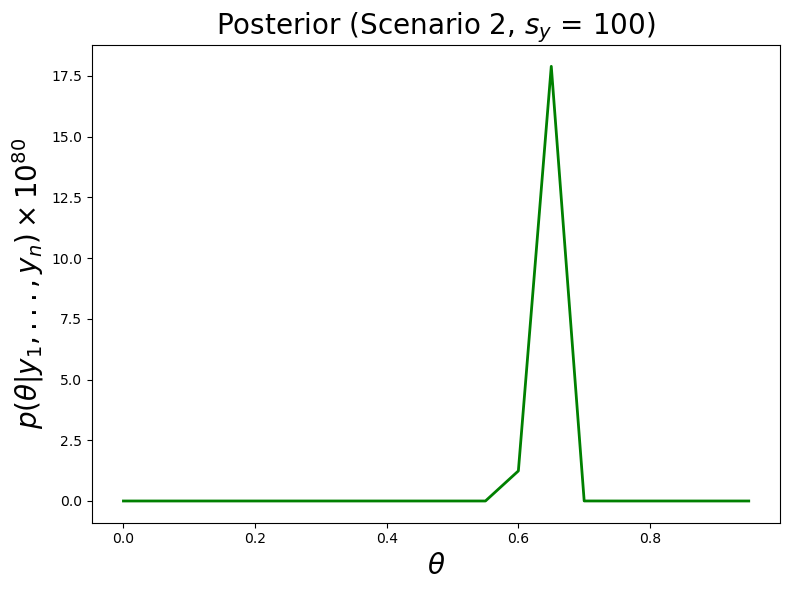

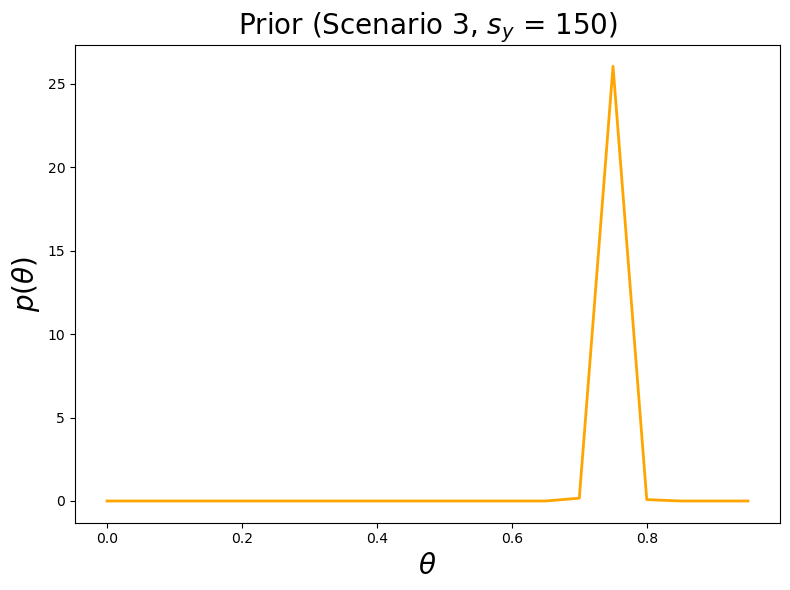

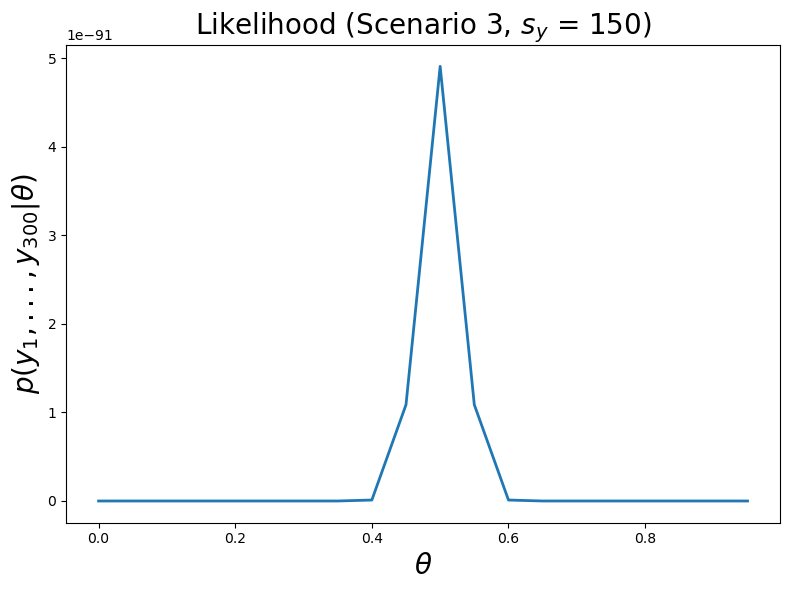

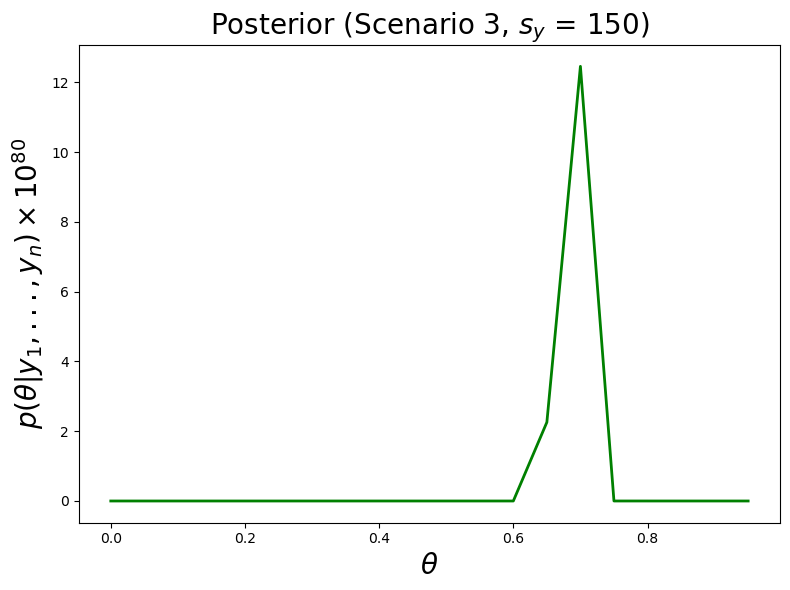

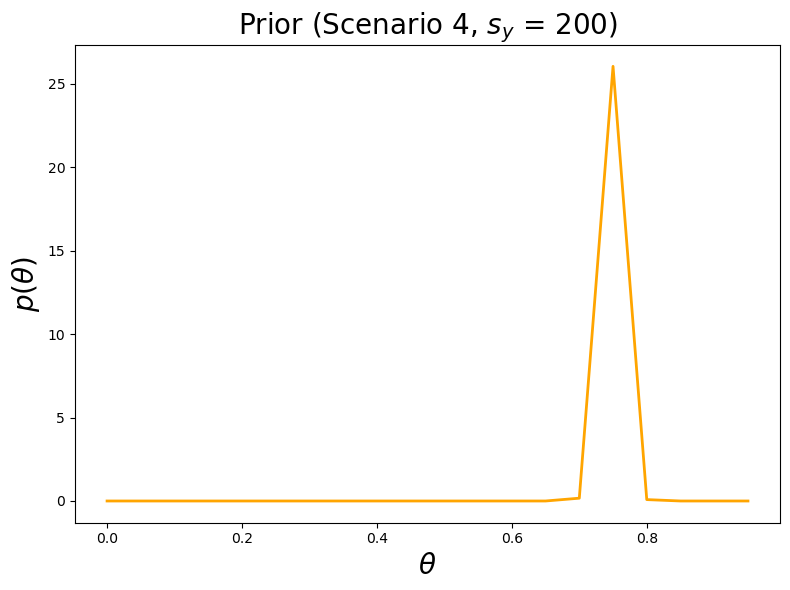

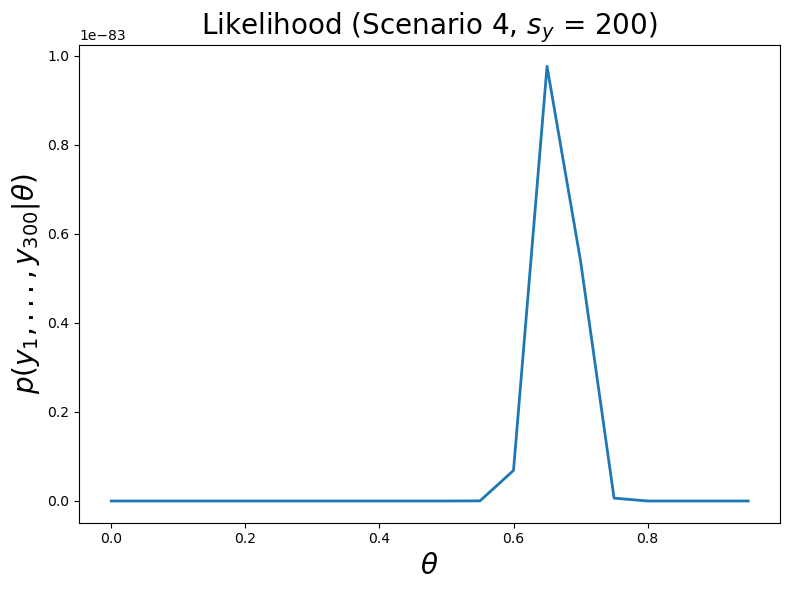

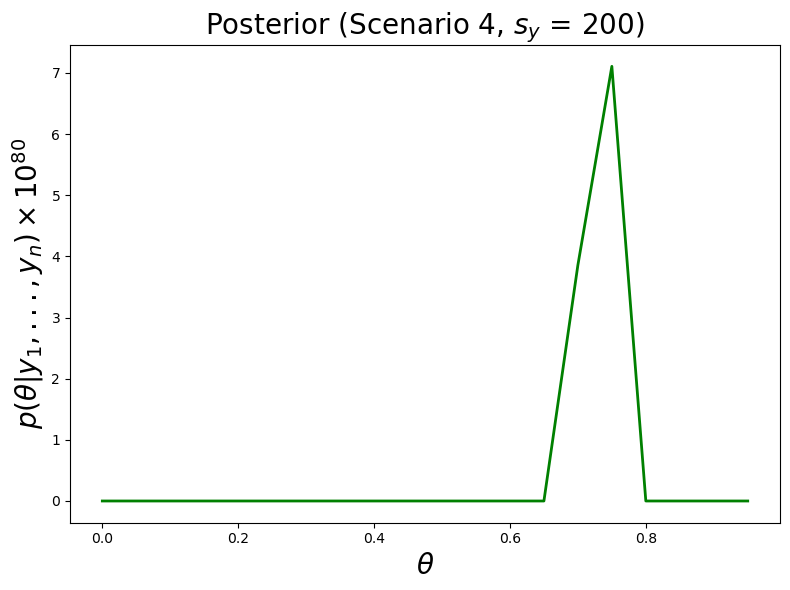

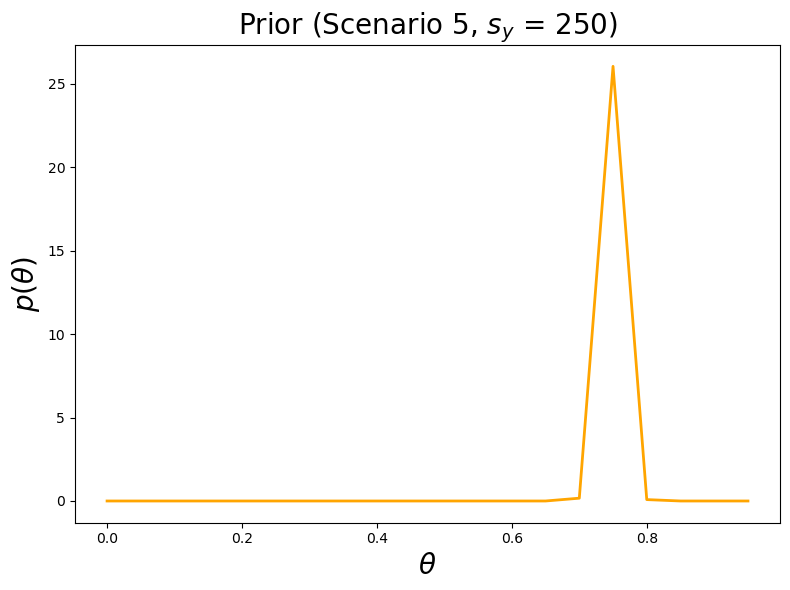

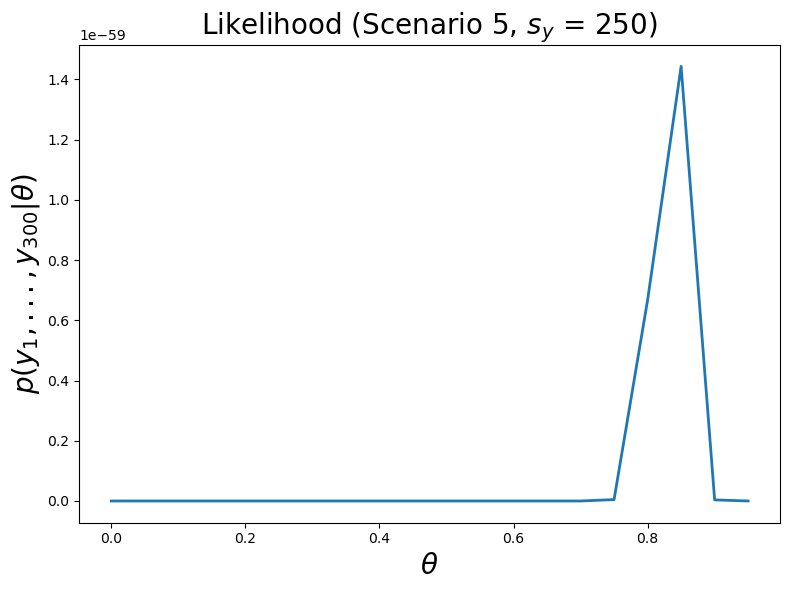

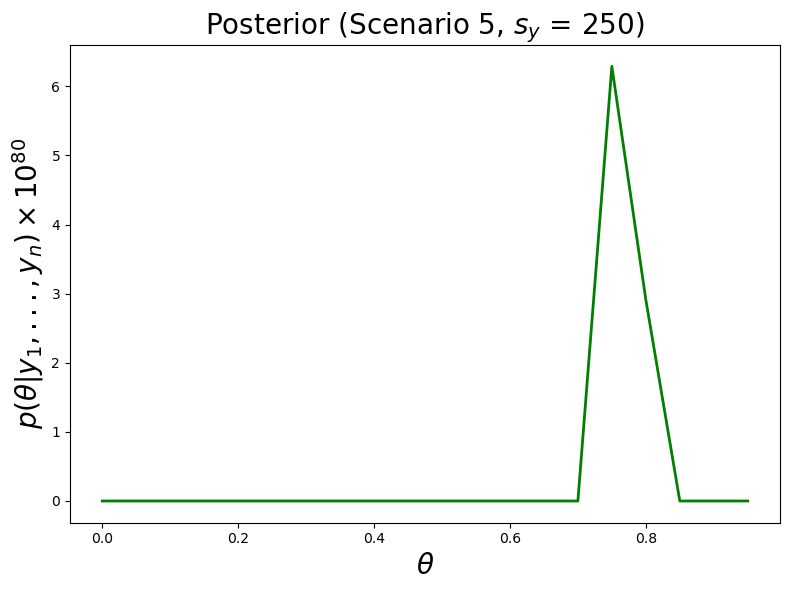

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta
import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# Define the number of scenarios
num_scenarios = 5

# Define different values of sy for each scenario
sy_values = [50, 100, 150, 200, 250]

# Create a grid of theta values
theta = np.arange(0, 1, 0.05)

for i, sy in enumerate(sy_values):
    n = 300  # Total number of samples
    
    # Generate random values of 'a' between 0.2 and 0.8
    a_prior = 600
    b_prior = 200
    
    # Calculate parameters for the posterior beta distribution
    a_post = a_prior + sy
    b_post = b_prior + n - sy
    
    binom_likelihood = theta**sy * (1 - theta)**(n - sy) 
    betapost = [beta.pdf(r, a_post, b_post, 0, 1) for r in theta]
    betaprior = [beta.pdf(r, a_prior, b_prior, 0, 1) for r in theta]

    # Plot the Prior distribution
    plt.figure(figsize=(8, 6))
    plt.plot(theta, betaprior, linewidth=2, markersize=12, color="orange")
    plt.title(f"Prior (Scenario {i+1}, $s_y$ = {sy})", fontsize=20)
    plt.xlabel(r'$\theta$', fontsize=20)
    plt.ylabel(r'$p(\theta)$', fontsize=20)
    plt.tight_layout()
    plt.show()

    # Plot the Likelihood
    plt.figure(figsize=(8, 6))
    plt.plot(theta, binom_likelihood, linewidth=2, markersize=12)
    plt.title(f"Likelihood (Scenario {i+1}, $s_y$ = {sy})", fontsize=20)
    plt.xlabel(r'$\theta$', fontsize=20)
    plt.ylabel(r'$p(y_1, ..., y_{300} | \theta)$', fontsize=20)
    plt.tight_layout()
    plt.show()

    # Plot the Posterior distribution
    plt.figure(figsize=(8, 6))
    plt.plot(theta, betapost, linewidth=2, markersize=12, color="green")
    plt.title(f"Posterior (Scenario {i+1}, $s_y$ = {sy})", fontsize=20)
    plt.xlabel(r'$\theta$', fontsize=20)
    plt.ylabel(r'$p(\theta | y_1, ..., y_n) \times 10^{80}$', fontsize=20)
    plt.tight_layout()
    plt.show()


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta
import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# Define the number of scenarios
num_scenarios = 5

# Define different values of sy for each scenario
sy_values = [50, 100, 150, 200, 250]

# Create a grid of theta values
theta = np.arange(0, 1, 0.05)

for i, sy in enumerate(sy_values):
    n = 300  # Total number of samples
    
    # Generate random values of 'a' between 0.2 and 0.8
    a_prior = np.random.uniform(0.2, 0.8) * 10
    b_prior = (1 - a_prior / 10) * 10
    
    # Calculate parameters for the posterior beta distribution
    a_post = a_prior + sy
    b_post = b_prior + n - sy
    
    binom_likelihood = theta**sy * (1 - theta)**(n - sy) * 10**80
    betapost = [beta.pdf(r, a_post, b_post, 0, 1) for r in theta]
    betaprior = [beta.pdf(r, a_prior, b_prior, 0, 1) for r in theta]

    # Plot the Prior distribution
    plt.figure(figsize=(8, 6))
    plt.plot(theta, betaprior, linewidth=2, markersize=12, color="orange")
    plt.title(f"Prior (Scenario {i+1}, $s_y$ = {sy})", fontsize=20)
    plt.xlabel(r'$\theta$', fontsize=20)
    plt.ylabel(r'$p(\theta)$', fontsize=20)
    plt.tight_layout()
    plt.savefig(f'prior_scenario_{i+1}.png')
    plt.close()

    # Plot the Likelihood
    plt.figure(figsize=(8, 6))
    plt.plot(theta, binom_likelihood, linewidth=2, markersize=12)
    plt.title(f"Likelihood (Scenario {i+1}, $s_y$ = {sy})", fontsize=20)
    plt.xlabel(r'$\theta$', fontsize=20)
    plt.ylabel(r'$p(y_1, ..., y_{300} | \theta)$', fontsize=20)
    plt.tight_layout()
    plt.savefig(f'likelihood_scenario_{i+1}.png')
    plt.close()

    # Plot the Posterior distribution
    plt.figure(figsize=(8, 6))
    plt.plot(theta, betapost, linewidth=2, markersize=12, color="green")
    plt.title(f"Posterior (Scenario {i+1}, $s_y$ = {sy})", fontsize=20)
    plt.xlabel(r'$\theta$', fontsize=20)
    plt.ylabel(r'$p(\theta | y_1, ..., y_n) \times 10^{80}$', fontsize=20)
    plt.tight_layout()
    plt.savefig(f'posterior_scenario_{i+1}.png')
    plt.close()
